In [1]:
import numpy as np
import pandas as pd

In [2]:
df= pd.read_csv("Iris.csv")

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df = df.iloc[:, 1:]

In [5]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [6]:
df["Species"] = encoder.fit_transform(df["Species"])

In [7]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


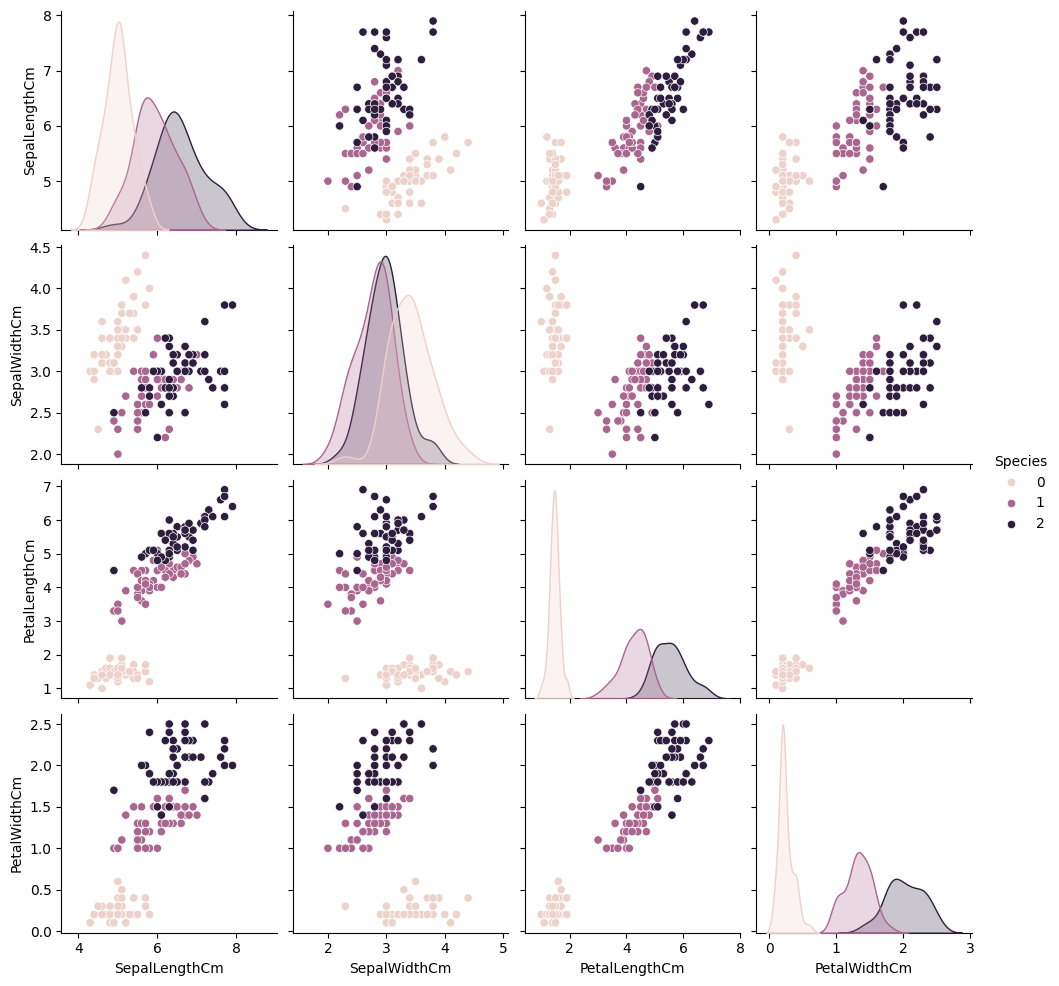

In [8]:
import seaborn as sns
sns.pairplot(df,hue="Species")

To make the classification task difficult on thsi dataset we will choose only sepalwidth and sepal length because classification on that plot seems a bit difficult then other columns

In [9]:
df = df[df["Species"] != 0][["SepalLengthCm", "SepalWidthCm", "Species"]]

In [10]:
df.shape

(100, 3)

In [11]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [13]:
clf1 = LogisticRegression()
clf2 = RandomForestClassifier()
clf3 = KNeighborsClassifier()

In [14]:
estimators = [("lr",clf1),("rf",clf2),("knn",clf3)]

In [15]:
for estimator in estimators:
    x = cross_val_score(estimator[1],X,y,cv = 10, scoring = 'accuracy')
    print(estimator[0], np.round(np.mean(x),2))

lr 0.75
rf 0.63
knn 0.62


estimator[1] means the model inside the tuple and np.mean(x) give the average accuracy after 10 folds

In [16]:
from sklearn.ensemble import VotingClassifier

In [17]:
vc = VotingClassifier(estimators = estimators)
x = cross_val_score(vc,X,y,cv=10, scoring="accuracy")
print(np.round(np.mean(x),2))

0.66


In [18]:
vc1 = VotingClassifier(estimators= estimators, voting ="soft")
x = cross_val_score(vc,X,y,cv=10, scoring="accuracy")
print(np.round(np.mean(x),2))

0.67


In [20]:
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):

            vc = VotingClassifier(estimators = estimators, voting = "soft",weights = [i,j,k])
            x = cross_val_score(vc,X,y,cv=10, scoring="accuracy")
            print("for i={} , j = {} , k = {}".format(i,j,k),np.round(np.mean(x),2))

for i=1 , j = 1 , k = 1 0.66
for i=1 , j = 1 , k = 2 0.65
for i=1 , j = 1 , k = 3 0.66
for i=1 , j = 2 , k = 1 0.61
for i=1 , j = 2 , k = 2 0.63
for i=1 , j = 2 , k = 3 0.64
for i=1 , j = 3 , k = 1 0.63
for i=1 , j = 3 , k = 2 0.63
for i=1 , j = 3 , k = 3 0.63
for i=2 , j = 1 , k = 1 0.69
for i=2 , j = 1 , k = 2 0.66
for i=2 , j = 1 , k = 3 0.67
for i=2 , j = 2 , k = 1 0.65
for i=2 , j = 2 , k = 2 0.67
for i=2 , j = 2 , k = 3 0.65
for i=2 , j = 3 , k = 1 0.65
for i=2 , j = 3 , k = 2 0.64
for i=2 , j = 3 , k = 3 0.64
for i=3 , j = 1 , k = 1 0.71
for i=3 , j = 1 , k = 2 0.68
for i=3 , j = 1 , k = 3 0.69
for i=3 , j = 2 , k = 1 0.68
for i=3 , j = 2 , k = 2 0.64
for i=3 , j = 2 , k = 3 0.65
for i=3 , j = 3 , k = 1 0.69
for i=3 , j = 3 , k = 2 0.67
for i=3 , j = 3 , k = 3 0.64
